Here, we demonstrate that the adverserial training removes the relevant categorical information from the bias term:

In [91]:
import os

import pandas as pd
import scanpy as sc
import numpy as np

from sklearn.metrics import normalized_mutual_info_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.preprocess import embed_tf_activity

In [3]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

In [9]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

Load the model and associated data:

In [5]:
trainer = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_fullbest_trainer.pickle'))
mod = trainer.mod

test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()

In [10]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

First, let's see what the loss looks like across epochs:

In [14]:
train_stats_df = trainer.stats['train'].copy()
# train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() # delete this

/tmp/ipykernel_3969489/186479417.py:33: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
/tmp/ipykernel_3969489/186479417.py:45: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[2])


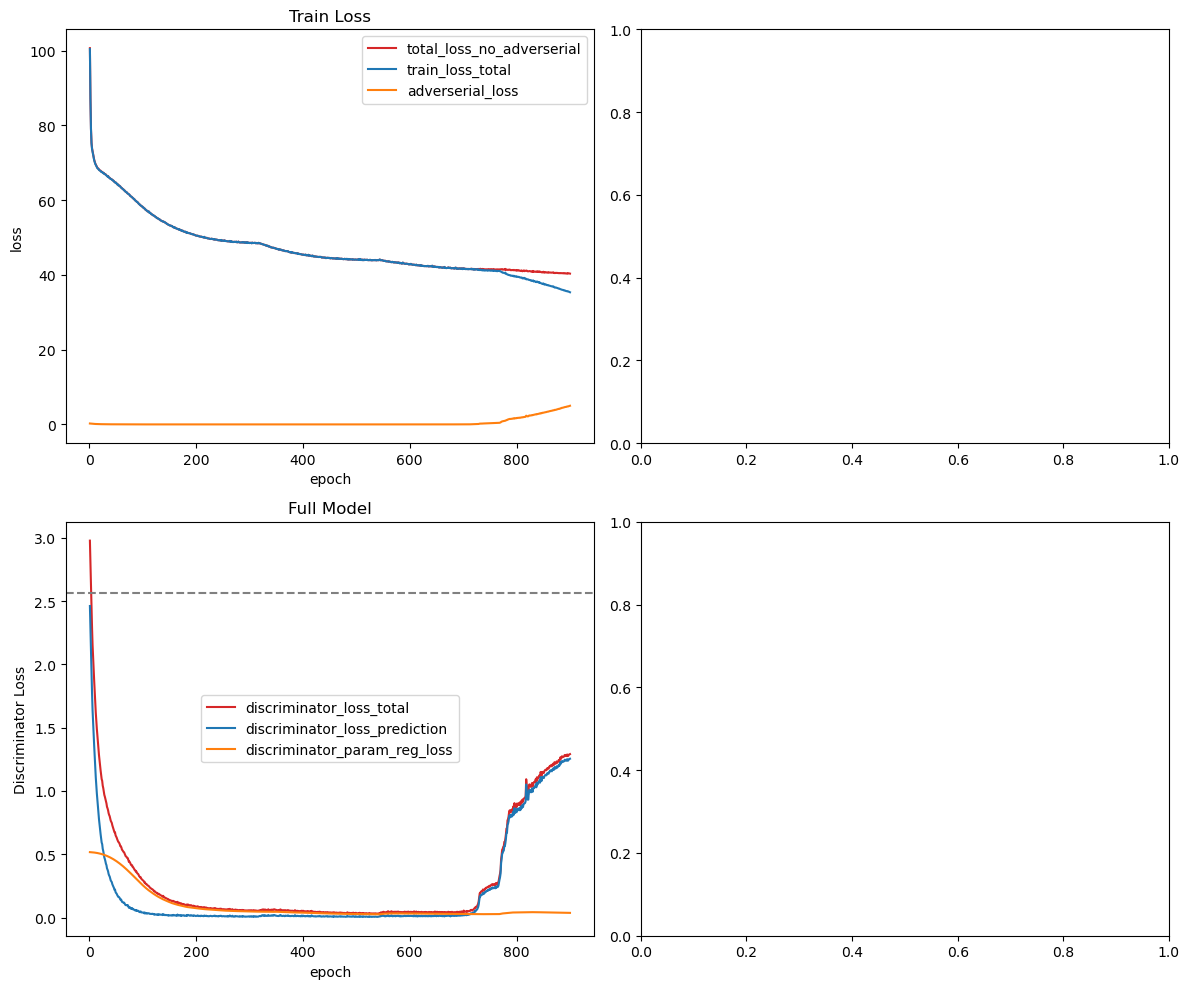

In [20]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,10))
ax = ax.flatten()

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)


# Plot 1: full model, adverserial loss
loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_loss', 'output_param_reg_loss', 'vae_param_reg_loss', 'kl_divergence']
loss_cols = ['train_loss_total'] + loss_cols_main + ['adverserial_loss']
viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
ax[0].legend(loc='best')#, bbox_to_anchor=(1.05, 0.5))
ax[0].set_title('Train Loss')


# Plot 3: full model, discriminator loss
loss_cols_disc = ['discriminator_loss_total',
       'discriminator_loss_prediction', 'discriminator_param_reg_loss']
viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[2])
n_cat = trainer.discriminator['discriminators']['seurat_annotations'].classifier[1].fc_layers[0][0].out_features
ax[2].axhline(y=np.log(n_cat), color='gray', linestyle='--')

ax[2].legend(loc='best')
ax[2].set_ylabel('Discriminator Loss')
ax[2].set_title('Full Model')

fig.tight_layout()

Next, let's see what the global bias looks like in UMAP space. To do this, we run the following prediction: for each condition (stimulation + cell type), we predict what that cell type would look like in the opposite stimulation condition from ALL the in-distribution data (from all other conditions). 

In [64]:
train_cells = trainer.X_train.index.tolist()
stim_map = {'STIM': 1, 'CTRL': 0}

cov_idx_map = dict(zip(mod.signaling_network.covariates['seurat_annotations'], 
                       mod.signaling_network.covariates_idx['seurat_annotations']))
cov_rev_map = {v:k for k,v in cov_idx_map.items()}

In [49]:
full_expr, full_X, full_covariates = None, None, None
for cond in tf_adata.obs.loc[test_cells, :].condition.unique():
    stim, ct = cond.split('^')
    
    expr_test = mod.df_to_tensor(mod.expr.loc[train_cells, :])

    X_test_df = pd.DataFrame(data = {'IFNB1': [stim_map[stim]]*len(train_cells)})
    X_test = mod.df_to_tensor(X_test_df)

    covariates_idx_test = torch.tensor([cov_idx_map[ct]]*len(train_cells), 
                                       device = mod.device, dtype = torch.int64).view(-1,1)
    
    if full_expr is None:
        full_expr = expr_test
    else: 
        full_expr = torch.cat((full_expr, expr_test), dim = 0)
        
    if full_X is None:
        full_X = X_test
    else: 
        full_X = torch.cat((full_X, X_test), dim = 0)

    if full_covariates is None:
        full_covariates = covariates_idx_test
    else: 
        full_covariates = torch.cat((full_covariates, covariates_idx_test), dim = 0)
        
mod.eval()
with torch.inference_mode():
    y_predicted, Y_full, biases = mod(X_in = full_X, covariates_idx = full_covariates, expr = full_expr)
    bias_global, bias_mu, bias_log_sigma_squared = biases

Clustering and dimensionality reduction:

In [77]:
obs = pd.DataFrame(full_covariates.detach().cpu().numpy())
obs.columns = ['seurat_annotations']
obs.seurat_annotations = obs.seurat_annotations.map(cov_rev_map)

onehot_df = pd.get_dummies(obs.seurat_annotations).astype(int)
one_hot = sc.AnnData(X = onehot_df, obs = obs)
embed_tf_activity(one_hot, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1, 
                 n_components = one_hot.shape[1] - 1)

np.random.seed(seed)
rand_idx = np.random.permutation(onehot_df.index)
rand_obs = obs.copy()
rand_obs.index = rand_idx
rand = sc.AnnData(X = onehot_df.loc[rand_idx, :], obs = rand_obs)
embed_tf_activity(rand, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1, 
                 n_components = rand.shape[1] - 1)


bias_adata = sc.AnnData(X = bias_global.detach().cpu().numpy(), obs = obs)
embed_tf_activity(bias_adata, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [154]:
def adata_dimviz(adata, reduction_type, cat, subset_idx = None):
    viz_df = pd.DataFrame(adata.obsm['X_' + reduction_type])
    viz_df = pd.concat([viz_df, pd.DataFrame(adata.obs[cat]).reset_index(drop = True)], ignore_index = True, axis = 1)

    viz_df.columns = [reduction_type.upper() + str(i+1) for i in range(viz_df.shape[1])]
    viz_df.columns = viz_df.columns[:-1].tolist() + [cat]
    
    if subset_idx is not None:
        viz_df = viz_df.loc[subset_idx, :]
    
    return viz_df

We'll visualize a random subset of 5000 cells because the dataset is large.

In [167]:
adata_types = ['Perfect Information', 'Completely Random', 
                     'Model No Adverserial', 'Model with Adverserial']
adata_dict = dict(zip(adata_types, 
                     [one_hot, rand, None, bias_adata]))

The top left panel is clustering/dimreduction results on one-hot encodings of the predicted cell types. The top right panel is this same information, but with the barcodes permuted. These reppresent baseline NMI values from the clustering pipeline. 

''

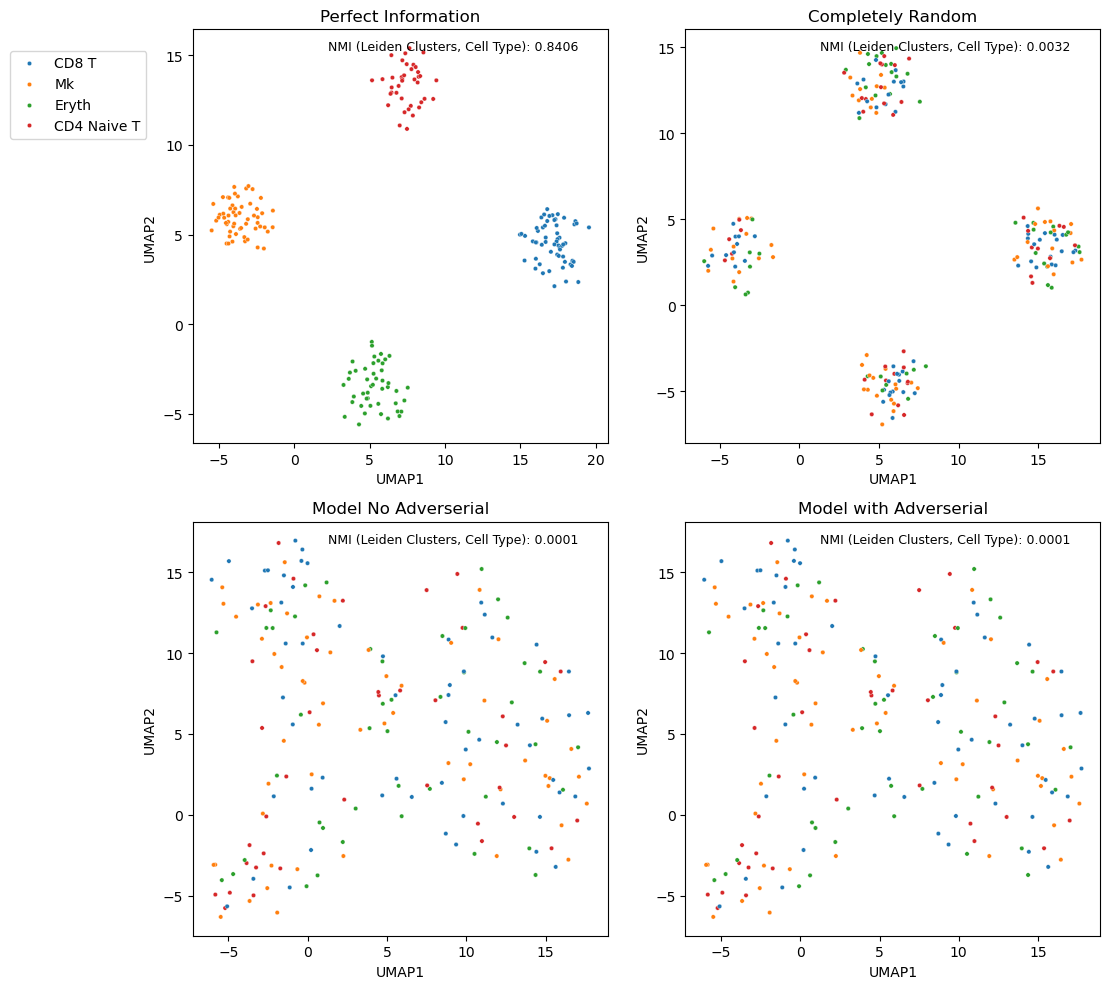

In [193]:
fig, ax = plt.subplots(ncols = 2, nrows = 2, figsize = (10,10))
ax = ax.flatten()

subset_size = 5000
subset_cells = np.random.choice(list(range(y_predicted.shape[0])), size=subset_size, replace=False)

for i, (adata_type, adata) in enumerate(adata_dict.items()):
    viz_df = adata_dimviz(adata = adata, reduction_type = 'umap', cat = 'seurat_annotations', 
                         subset_idx = subset_cells)
    nmi = normalized_mutual_info_score(adata.obs.leiden, adata.obs.seurat_annotations)

    sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = 'seurat_annotations', 
                    s=10,
                    ax = ax[i])
    ax[i].annotate('NMI (Leiden Clusters, Cell Type): {:.4f}'.format(nmi),
                    xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
    ax[i].set_title(adata_type)

lines, labels = ax[3].get_legend_handles_labels()
fig.legend(lines, labels, loc="upper left", bbox_to_anchor=(-0.125, 0.95))
for ax_ in ax:
    ax_.legend().remove()
    
    
fig.tight_layout()
;